🌾 CROPS - Model Evaluation

📊 Loading dataset...
   Loaded 5000 records

🤖 Loading models...
   ✅ Models loaded successfully!

📊 Preparing data...
   Original features: ['farm_id', 'barangay', 'variety', 'soil_type', 'season', 'seeding_method', 'fertilizer_kg_ha', 'temperature_avg', 'rainfall_mm', 'humidity_avg', 'historical_yield_tons_ha']
   Features after scaling: 11 columns
   Feature names: ['farm_id', 'barangay', 'variety', 'soil_type', 'season', 'seeding_method', 'fertilizer_kg_ha', 'temperature_avg', 'rainfall_mm', 'humidity_avg', 'historical_yield_tons_ha']
   Training: 4000 records
   Testing:  1000 records

🧠 Making predictions...
   ✅ Predictions complete

📊 MODEL COMPARISON (Test Set)
        Model   RMSE    MAE     R²  MAPE (%)
Random Forest 0.2716 0.2203 0.8181    4.6387
      XGBoost 0.2687 0.2190 0.8221    4.6342
     Ensemble 0.2639 0.2155 0.8284    4.5504

📈 Generating learning curves...


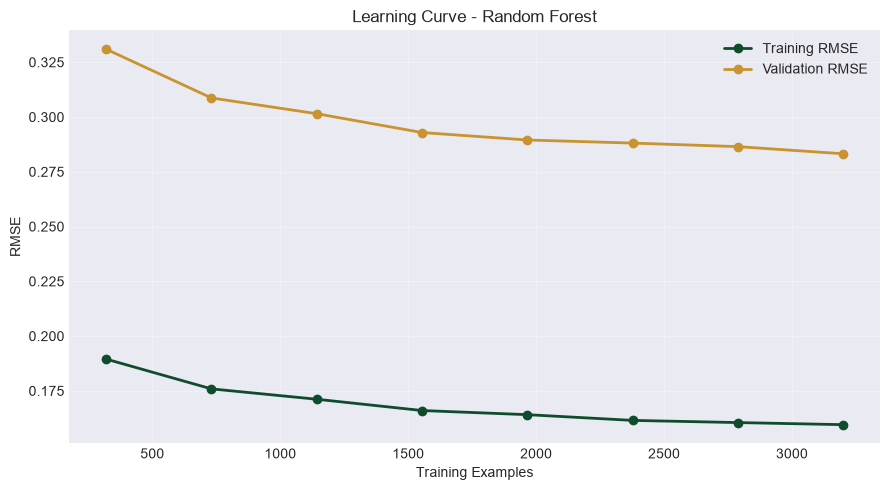

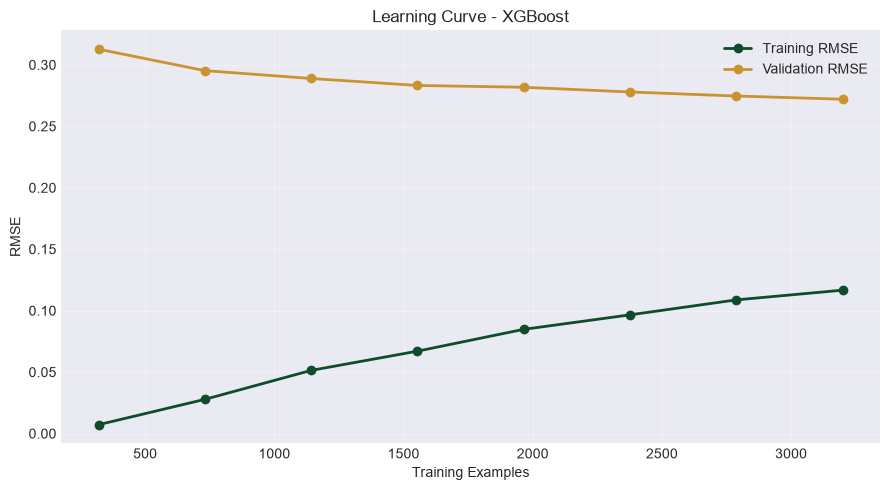


🌲 Feature Importance (Random Forest)

Top 10 Features:
                 Feature  Importance
                 variety    0.658881
        fertilizer_kg_ha    0.116397
historical_yield_tons_ha    0.069820
         temperature_avg    0.045905
             rainfall_mm    0.044447
          seeding_method    0.021388
                 farm_id    0.016575
            humidity_avg    0.016229
                barangay    0.005327
               soil_type    0.004684


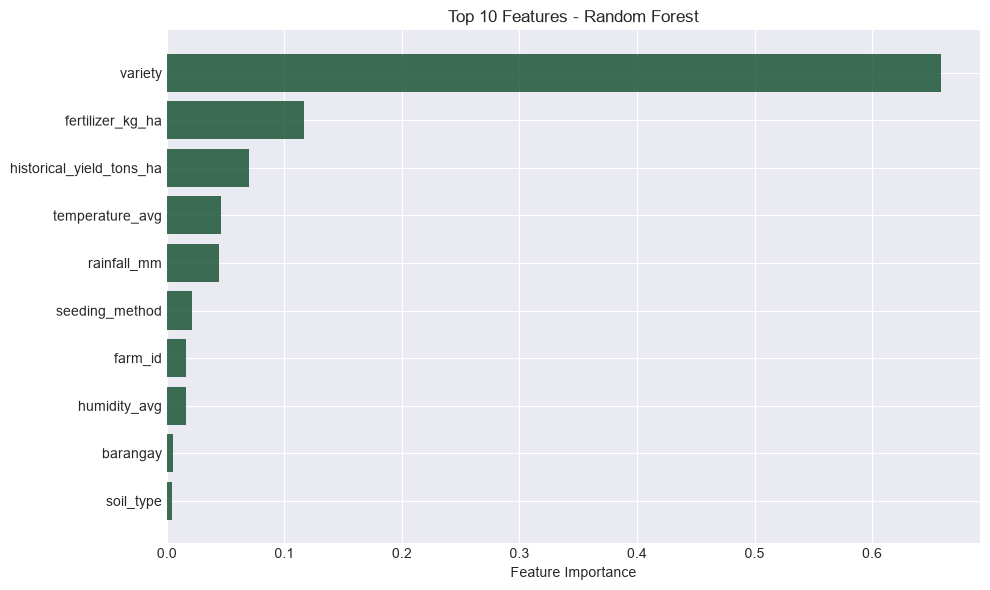


📊 Actual vs Predicted (Ensemble)


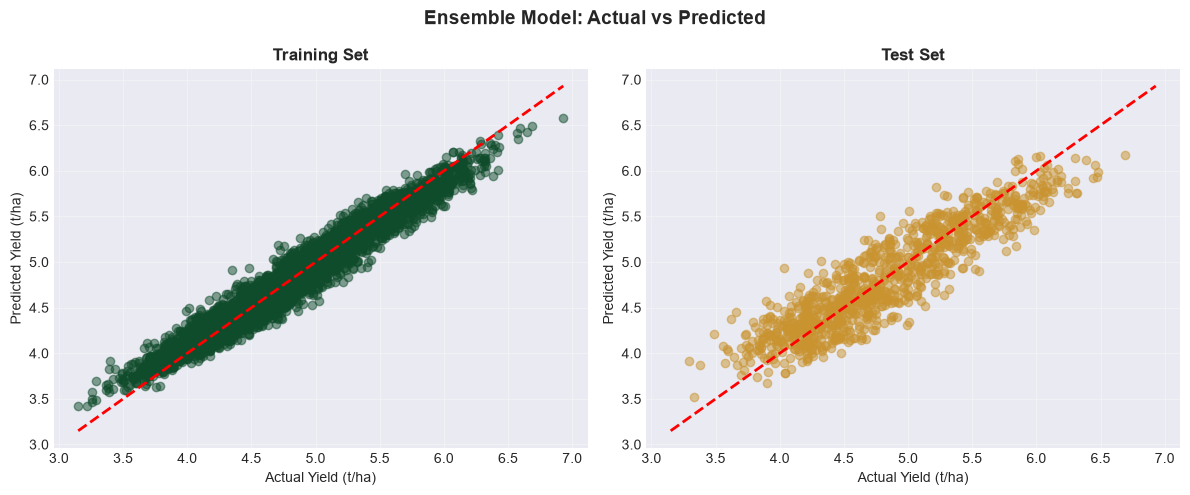


📊 Residual Analysis


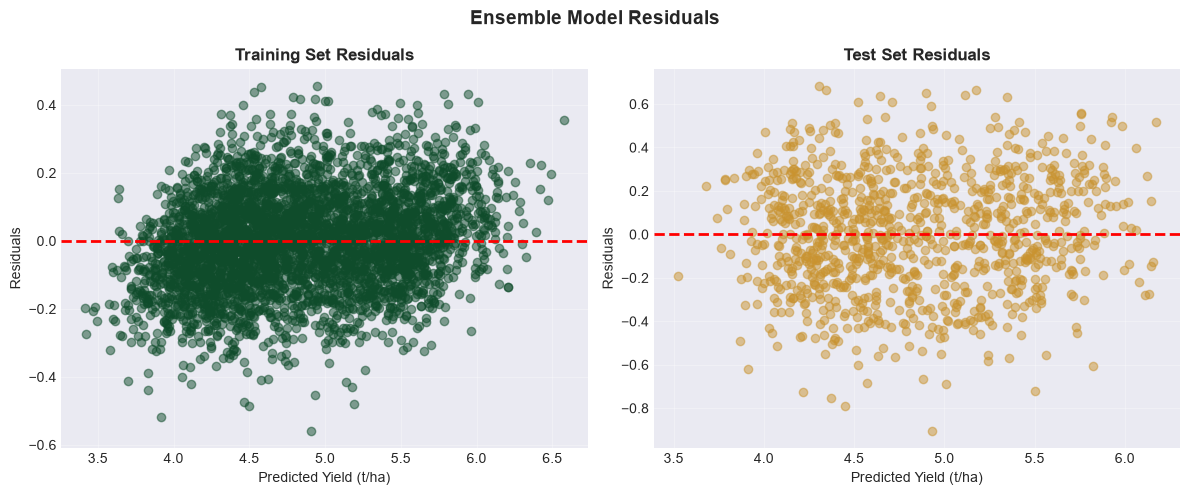


📊 Cross-Validation (5-fold)
Random Forest CV R²: 0.8013 (±0.0068)
XGBoost CV R²:      0.8146 (±0.0094)

✅ EVALUATION COMPLETE

🏆 Best Model: Ensemble
   Test RMSE: 0.2639
   Test R²:   0.8284
   Test MAPE: 4.55%


In [2]:
# ============================================================
# CROPS - Model Evaluation Notebook
# Loads existing models and shows training metrics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("=" * 60)
print("🌾 CROPS - Model Evaluation")
print("=" * 60)

# ============================================================
# 1. LOAD DATA
# ============================================================
print("\n📊 Loading dataset...")
df = pd.read_csv('synthetic_rice_data.csv')
print(f"   Loaded {len(df)} records")

# ============================================================
# 2. LOAD MODELS
# ============================================================
print("\n🤖 Loading models...")

rf_model = joblib.load('model_rf.pkl')
xgb_model = joblib.load('model_xgb.pkl')
scaler = joblib.load('scaler.pkl')
label_encoders = joblib.load('label_encoders.pkl')
feature_names = joblib.load('feature_names.pkl')

print("   ✅ Models loaded successfully!")

# ============================================================
# 3. PREPARE DATA
# ============================================================
print("\n📊 Preparing data...")

X = df.drop(columns=['yield_tons_ha'])
y = df['yield_tons_ha']

# ✅ Check if farm_id exists and keep it (don't drop it)
print(f"   Original features: {X.columns.tolist()}")

# Encode categorical columns
categorical_cols = ['barangay', 'variety', 'soil_type', 'season', 'seeding_method']
for col in categorical_cols:
    if col in X.columns:
        X[col] = label_encoders[col].transform(X[col])

# ✅ IMPORTANT: DO NOT drop farm_id — keep it as a feature
# The scaler was trained with farm_id, so we need to keep it

# ✅ Scale ALL features (matching exactly what the scaler was trained on)
X_scaled = scaler.transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print(f"   Features after scaling: {X.shape[1]} columns")
print(f"   Feature names: {X.columns.tolist()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"   Training: {len(X_train)} records")
print(f"   Testing:  {len(X_test)} records")

# ============================================================
# 4. MAKE PREDICTIONS
# ============================================================
print("\n🧠 Making predictions...")

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
ensemble_train_pred = (rf_train_pred + xgb_train_pred) / 2
ensemble_test_pred = (rf_test_pred + xgb_test_pred) / 2

print("   ✅ Predictions complete")

# ============================================================
# 5. CALCULATE METRICS (Training + Test)
# ============================================================
def calculate_metrics(y_true, y_pred, name, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {
        'Model': name,
        'Set': set_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE (%)': mape
    }

metrics = []

# Random Forest - Training
metrics.append(calculate_metrics(y_train, rf_train_pred, 'Random Forest', 'Training'))

# Random Forest - Test
metrics.append(calculate_metrics(y_test, rf_test_pred, 'Random Forest', 'Test'))

# XGBoost - Training
metrics.append(calculate_metrics(y_train, xgb_train_pred, 'XGBoost', 'Training'))

# XGBoost - Test
metrics.append(calculate_metrics(y_test, xgb_test_pred, 'XGBoost', 'Test'))

# Ensemble - Training
metrics.append(calculate_metrics(y_train, ensemble_train_pred, 'Ensemble', 'Training'))

# Ensemble - Test
metrics.append(calculate_metrics(y_test, ensemble_test_pred, 'Ensemble', 'Test'))

# Create comparison table
comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.round(4)

print("\n" + "=" * 80)
print("📊 FULL MODEL COMPARISON (Training vs Test)")
print("=" * 80)
print(comparison_df.to_string(index=False))

# ============================================================
# 5b. OVERFITTING CHECK
# ============================================================
print("\n" + "=" * 80)
print("🔍 OVERFITTING CHECK (Training vs Test Gap)")
print("=" * 80)

# Get the test and training R² for each model
rf_train_r2 = calculate_metrics(y_train, rf_train_pred, 'RF', 'Train')['R²']
rf_test_r2 = calculate_metrics(y_test, rf_test_pred, 'RF', 'Test')['R²']
xgb_train_r2 = calculate_metrics(y_train, xgb_train_pred, 'XGB', 'Train')['R²']
xgb_test_r2 = calculate_metrics(y_test, xgb_test_pred, 'XGB', 'Test')['R²']
ens_train_r2 = calculate_metrics(y_train, ensemble_train_pred, 'Ens', 'Train')['R²']
ens_test_r2 = calculate_metrics(y_test, ensemble_test_pred, 'Ens', 'Test')['R²']

print(f"\n📈 Random Forest:")
print(f"   Training R²: {rf_train_r2:.4f} | Test R²: {rf_test_r2:.4f} | Gap: {rf_train_r2 - rf_test_r2:.4f}")

print(f"\n📈 XGBoost:")
print(f"   Training R²: {xgb_train_r2:.4f} | Test R²: {xgb_test_r2:.4f} | Gap: {xgb_train_r2 - xgb_test_r2:.4f}")

print(f"\n📈 Ensemble:")
print(f"   Training R²: {ens_train_r2:.4f} | Test R²: {ens_test_r2:.4f} | Gap: {ens_train_r2 - ens_test_r2:.4f}")

# Overfitting verdict
if ens_train_r2 - ens_test_r2 < 0.1:
    print("\n✅ The Ensemble model shows minimal overfitting (gap < 0.1). Good generalization!")
else:
    print("\n⚠️ The Ensemble model shows some overfitting. Consider adding regularization.")

# ============================================================
# 6. LEARNING CURVES
# ============================================================
print("\n📈 Generating learning curves...")

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='neg_mean_squared_error', n_jobs=-1
    )
    
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))
    
    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE', color='#0f4c2b', linewidth=2)
    plt.plot(train_sizes, val_rmse, 'o-', label='Validation RMSE', color='#c9932f', linewidth=2)
    plt.xlabel('Training Examples')
    plt.ylabel('RMSE')
    plt.title(f'Learning Curve - {title}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_learning_curve(rf_model, X_train, y_train, 'Random Forest')
plot_learning_curve(xgb_model, X_train, y_train, 'XGBoost')

# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================
print("\n🌲 Feature Importance (Random Forest)")

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(rf_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'][:10], rf_importance['Importance'][:10], 
         color='#0f4c2b', alpha=0.8)
plt.xlabel('Feature Importance')
plt.title('Top 10 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# 8. ACTUAL vs PREDICTED
# ============================================================
print("\n📊 Actual vs Predicted (Ensemble)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
axes[0].scatter(y_train, ensemble_train_pred, alpha=0.5, color='#0f4c2b')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Yield (t/ha)')
axes[0].set_ylabel('Predicted Yield (t/ha)')
axes[0].set_title('Training Set', fontweight='bold')
axes[0].grid(alpha=0.3)

# Testing
axes[1].scatter(y_test, ensemble_test_pred, alpha=0.5, color='#c9932f')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Yield (t/ha)')
axes[1].set_ylabel('Predicted Yield (t/ha)')
axes[1].set_title('Test Set', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Ensemble Model: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 9. RESIDUALS
# ============================================================
print("\n📊 Residual Analysis")

residuals_train = y_train - ensemble_train_pred
residuals_test = y_test - ensemble_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training residuals
axes[0].scatter(ensemble_train_pred, residuals_train, alpha=0.5, color='#0f4c2b')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Yield (t/ha)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Training Set Residuals', fontweight='bold')
axes[0].grid(alpha=0.3)

# Testing residuals
axes[1].scatter(ensemble_test_pred, residuals_test, alpha=0.5, color='#c9932f')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Yield (t/ha)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Test Set Residuals', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Ensemble Model Residuals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 10. CROSS-VALIDATION
# ============================================================
print("\n📊 Cross-Validation (5-fold)")

from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')

print(f"Random Forest CV R²: {rf_cv.mean():.4f} (±{rf_cv.std():.4f})")
print(f"XGBoost CV R²:      {xgb_cv.mean():.4f} (±{xgb_cv.std():.4f})")

# ============================================================
# 11. FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("✅ EVALUATION COMPLETE")
print("=" * 60)

best_model = comparison_df.loc[comparison_df['R²'].idxmax()]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   Test RMSE: {best_model['RMSE']:.4f}")
print(f"   Test R²:   {best_model['R²']:.4f}")
print(f"   Test MAPE: {best_model['MAPE (%)']:.2f}%")